<a href="https://colab.research.google.com/github/WahyuKhairi06/NLP_IF23/blob/main/Tugas_Kelompok_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NLP : Klasifikasi Teks spam dan non spam pada email menggunakan Algoritma Multinomial Naive Bayes**

# import library

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. LOAD & CLEAN DATASET

In [8]:
print("--- Memuat dan Membersihkan Data ---")
df = pd.read_csv('email.csv')

# Membersihkan baris glitch/metadata jika ada
df = df[df['Category'].isin(['ham', 'spam'])]

# Mapping label teks ke angka numerik
df['Label'] = df['Category'].map({'ham': 0, 'spam': 1})

--- Memuat dan Membersihkan Data ---


# 2. SPLITTING DATA (80% Train, 20% Test)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Message'],
    df['Label'],
    test_size=0.2,
    random_state=42,
    stratify=df['Label']
)

print(f"Jumlah Data Training: {len(X_train)}")
print(f"Jumlah Data Testing : {len(X_test)}\n")

Jumlah Data Training: 4457
Jumlah Data Testing : 1115



# 3. PRAPROSES & EKSTRAKSI FITUR (Bag of Words)

In [10]:
# Menggunakan CountVectorizer yang otomatis melakukan Case Folding & Stopwords Removal
vectorizer = CountVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 4. PELATIHAN MODEL (Naive Bayes)

In [11]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

# 5. EVALUASI DAN HASIL

--- LAPORAN EVALUASI MODEL ---
Akurasi Keseluruhan: 98.39%

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.96      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



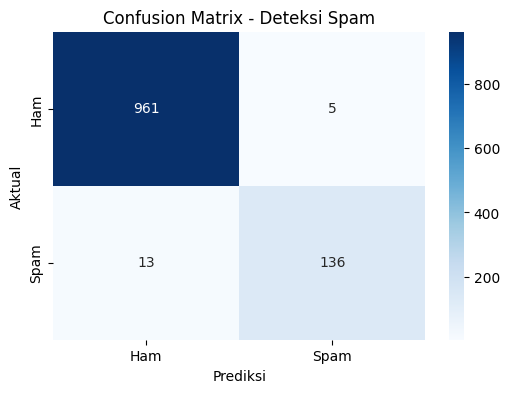

In [12]:
y_pred = model.predict(X_test_vec)

print("--- LAPORAN EVALUASI MODEL ---")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Deteksi Spam')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

# 8. DEMO

In [13]:
def prediksi_pesan_baru(teks):
    teks_vec = vectorizer.transform([teks])
    prediksi = model.predict(teks_vec)
    probability = model.predict_proba(teks_vec)[0]

    if prediksi[0] == 1:
        return f"🚨 SPAM (Keyakinan: {probability[1]*100:.2f}%)"
    else:
        return f"✅ BUKAN SPAM (Keyakinan: {probability[0]*100:.2f}%)"

print("\n--- UJI COBA DEMO ---")
# Contoh 1: Pesan spam tipikal
pesan_contoh_1 = "our account has been suspended due to unauthorized access. Click [link mencurigakan] to verify your identity immediately."
print(f"Pesan: '{pesan_contoh_1}'")
print(f"Hasil: {prediksi_pesan_baru(pesan_contoh_1)}\n")

# Contoh 2: Pesan normal (ham)
pesan_contoh_2 = "Hey, are we still meeting up for dinner tonight? Let me know when you are free haha"
print(f"Pesan: '{pesan_contoh_2}'")
print(f"Hasil: {prediksi_pesan_baru(pesan_contoh_2)}\n")


pesan_contoh_3 = "Hi, I’m interested in applying for an internship at the IT Directorate, Universitas Andalas. When are you available to discuss woth me :)?"
print(f"Pesan: '{pesan_contoh_3}'")
print(f"Hasil: {prediksi_pesan_baru(pesan_contoh_3)}")






--- UJI COBA DEMO ---
Pesan: 'our account has been suspended due to unauthorized access. Click [link mencurigakan] to verify your identity immediately.'
Hasil: 🚨 SPAM (Keyakinan: 99.61%)

Pesan: 'Hey, are we still meeting up for dinner tonight? Let me know when you are free haha'
Hasil: ✅ BUKAN SPAM (Keyakinan: 100.00%)

Pesan: 'Hi, I’m interested in applying for an internship at the IT Directorate, Universitas Andalas. When are you available to discuss woth me :)?'
Hasil: ✅ BUKAN SPAM (Keyakinan: 99.64%)
